In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from keras.datasets import fashion_mnist
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.optimizers import Adam

tf.keras.utils.set_random_seed(42)

## 1) Förbereda datan

- ladda in datan
- undersöka vilka klasser som finns
- se hur många bilder som finns
- identifiera eventuella obalanser


In [3]:
#Ladda in datan
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images_full, train_labels_full), (test_images, test_labels) = fashion_mnist.load_data()


print("Bilder i train set:", train_images_full.shape)
print("Bilder i test set:", test_images.shape)
print("Bilder totalt:", len(train_labels_full) + len(test_labels))
print("Klasser:", np.unique(test_labels))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Bilder i train set: (60000, 28, 28)
Bilder i test set: (10000, 28, 28)
Bilder totalt: 70000
Klasser: [0 1 2 3 4 5 6 7 8 9]


### Summering av dataset

- Datasetet innehåller 70,000 bilder där varje bild representeras i 28 x 28 pixels var.
- Datasetet är redan indelat i train-set - 60,000 bilder och test-set - 10,000. 
- Det finns 10 klasskategorier eller *labels* som bilderna kan hamna inom - *labels* är en vektor av integers från 0 till 9. Dessa representerar vilken sorts klädkategori bilder hamnar inom:

| Label       | Class       |
| ----------- | ----------- |
| 0 	      | T-shirt/top |
| 1 	      |  Trouser    |
| 2 	      |  Pullover   |
| 3 	      |  Dress      |
| 4 	      |  Coat       |
| 5 	      |  Sandal     |
| 6 	      |  Shirt      |
| 7 	      |  Sneaker    |
| 8 	      |  Bag        |
| 9 	      |  Ankle boot |

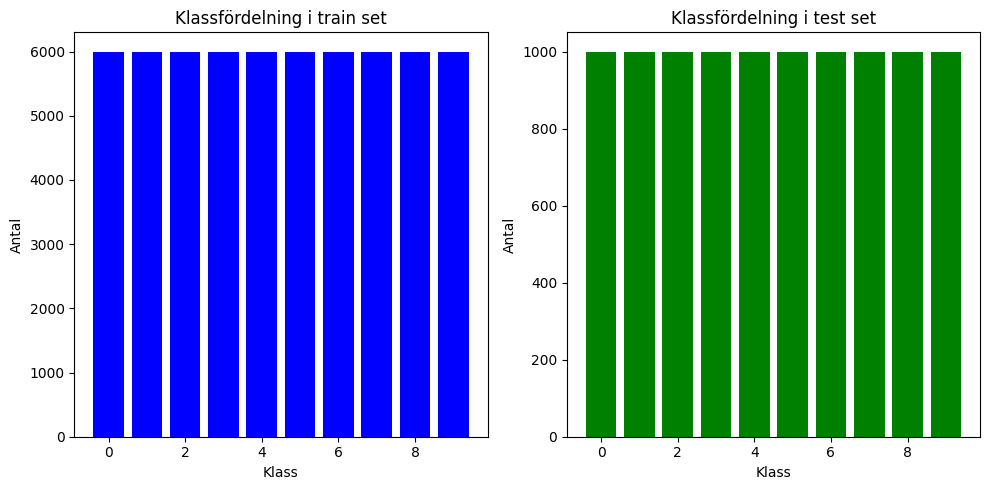

In [4]:
# Identifiera eventuella obalanser

classes_train, counts_train = np.unique(train_labels_full, return_counts=True)
classes_test, counts_test = np.unique(test_labels, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(classes_train, counts_train, color = 'blue')
axes[0].set_title('Klassfördelning i train set')
axes[0].set_xlabel('Klass')
axes[0].set_ylabel('Antal')

axes[1].bar(classes_test, counts_test, color = 'green')
axes[1].set_title('Klassfördelning i test set')
axes[1].set_xlabel('Klass')
axes[1].set_ylabel('Antal')

plt.tight_layout()
plt.show()


### Summering av klassfördelning

Klassfördelningen visar ett perfekt balanserat dataset igenom både train och test setet. 

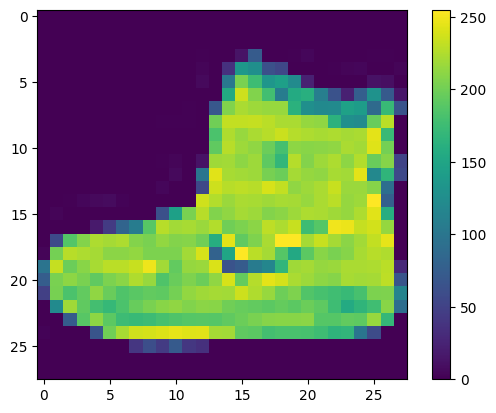

In [5]:
# Bild före preprocessing

plt.figure()
plt.imshow(train_images_full[0])
plt.colorbar()
plt.grid(False)
plt.show()

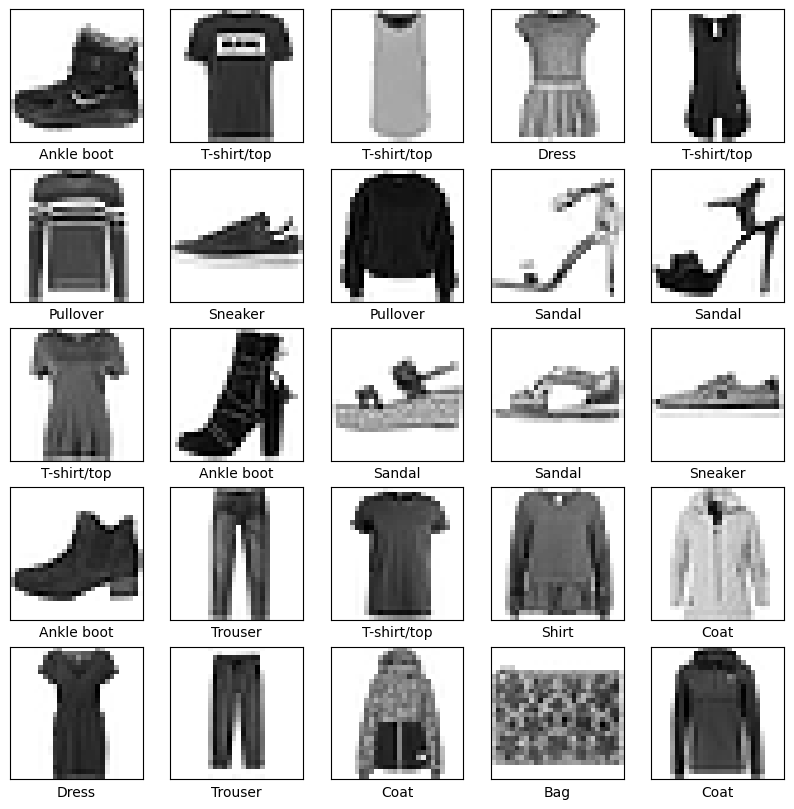

In [6]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Testa att normaliseringen funkade
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images_full[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels_full[i]])
plt.show()


## 2) Förbereda datan

- forma datan så att den fungerar med modellen:
    - skapa ett subset av träningsdatan
    - dela datan i train - val 
    - normalisera/skala bilderna


In [7]:
def create_balanced_subset(X, y, samples_per_class=700, random_state=42):

    rng = np.random.default_rng(random_state)
    selected_indices = []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]

        if len(class_indices) < samples_per_class:
            raise ValueError(
                f"Klassen {class_id} har bara {len(class_indices)} exempel, "
                f"men samples_per_class={samples_per_class}"
            )
        
        chosen_indices = rng.choice(
            class_indices,
            size=samples_per_class,
            replace=False
        )

        selected_indices.extend(chosen_indices)
    
    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    return X[selected_indices], y[selected_indices]


X_subset_raw, y_subset = create_balanced_subset(
    train_images_full,
    train_labels_full,
    samples_per_class=700,
    random_state=42
)

print("X_subset_raw:", X_subset_raw.shape)
print("y_subset:", y_subset.shape)



X_subset_raw: (7000, 28, 28)
y_subset: (7000,)


In [19]:
train_images, val_images, train_labels, val_labels = train_test_split(
    X_subset_raw,
    y_subset,
    test_size=0.20,
    random_state=42,
    stratify=y_subset
)

print("Train images:", train_images.shape)
print("Validation images:", val_images.shape)
print("Train labels:", train_labels.shape)
print("Validatio labels:", val_labels.shape)

Train images: (5600, 28, 28)
Validation images: (1400, 28, 28)
Train labels: (5600,)
Validatio labels: (1400,)


In [20]:
train_images_norm = train_images.astype("float32") / 255.0
val_images_norm = val_images.astype("float32") / 255.0
test_images_norm = test_images.astype("float32") / 255.0

print("Train imgs min/max:", train_images_norm.min(), train_images_norm.max())
print("Validation imgs min/max:", val_images_norm.min(), val_images_norm.max())
print("Test imgs shape:", test_images_norm.shape)

Train imgs min/max: 0.0 1.0
Validation imgs min/max: 0.0 1.0
Test imgs shape: (10000, 28, 28)


In [21]:
train_images_norm = train_images_norm[..., np.newaxis]
val_images_norm = val_images_norm[..., np.newaxis]
test_images_norm = test_images_norm[..., np.newaxis]

print("Train imgs shape efter kanal-dimension:", train_images_norm.shape)
print("Validation imgs shape efter kanal-dimension:", val_images_norm.shape)
print("Test imgs shape efter kanal-dimension:", test_images_norm.shape)

Train imgs shape efter kanal-dimension: (5600, 28, 28, 1)
Validation imgs shape efter kanal-dimension: (1400, 28, 28, 1)
Test imgs shape efter kanal-dimension: (10000, 28, 28, 1)


## 3) Bygga en modell

- skapa en första fungerande modell
- använda neurala nätverk (t.ex. CNN)
- säkerställa att modellen kan tränas


In [22]:
# Bygger en baseline CNN-model

def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),       # 128 neuroner 
        layers.Dense(10, activation="softmax")      # 10 klassser
    ])
    
    model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
    )
    
    return model

In [23]:
baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Vi skapade en baseline-modell med CNN-arkitektur. Modellen består av två convolutional layers (Conv2D) som används för att identifiera mönster i bilderna, följt av max pooling som minskar bilddimensionerna. Därefter används ett flatten-lager och dense-lager för klassificering. Det sista lagret har 10 neuroner eftersom Fashion MNIST innehåller 10 klasser. Softmax används för att modellen ska ge sannolikheter för varje klass.

In [25]:
history_baseline = baseline_model.fit(
    train_images_norm,
    train_labels,
    validation_data = (val_images_norm, val_labels),
    epochs=5,
    batch_size=32
)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.9004 - loss: 0.2673 - val_accuracy: 0.8743 - val_loss: 0.3682
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.9134 - loss: 0.2345 - val_accuracy: 0.8771 - val_loss: 0.3760
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9216 - loss: 0.2066 - val_accuracy: 0.8721 - val_loss: 0.3926
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.9320 - loss: 0.1797 - val_accuracy: 0.8679 - val_loss: 0.4246
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9418 - loss: 0.1545 - val_accuracy: 0.8714 - val_loss: 0.4353


### Träna baseline-modellen

Efter att baseline-modellen har byggts och compile:ats tränas den på vårt normaliserade träningsdata. 
Vi använder validation data för att kunna följa hur modellen presterar på data som den inte tränas direkt på.

I den första baseline använder vi 5 epochs och batch size 32. 
Resultatet sparas i `history_baseline`, vilket gör att vi senare kan visualisera utvecklingen av loss och accuracy under träningen.